# Anti-Swarm GNN — Complete Colab Pipeline
### Detecting Synthetic Consensus via Graph Attention Networks
---
**Author:** Sarah Sunday Moses | **v0.3** | Runtime: GPU (T4)  
**Stack:** PyTorch Geometric · cresci-2017 · IRA Troll Tweets · FastAPI plugin

**Pipeline:**
```
Auto-Download Data  →  Feature Engineering  →  Graph Construction
     →  Train/Val/Test Split  →  Baselines (3)  →  Anti-Swarm GAT
     →  Threshold Calibration  →  Feature Ablation (XAI)
     →  Attention Visualisation  →  Cluster Detection  →  FastAPI Plugin
```

In [ ]:
import os, glob, warnings, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
plt.rcParams.update({'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d27',
    'axes.edgecolor':'#444','axes.labelcolor':'#ccc','text.color':'#eee',
    'xtick.color':'#aaa','ytick.color':'#aaa','grid.color':'#333',
    'grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace'})
print('Imports OK')


Device: cuda
Imports OK


## Data Acquisition

Auto-downloads two public datasets. Falls back to synthetic mirror if network-restricted.


In [ ]:
import urllib.request, zipfile
os.makedirs('data', exist_ok=True)

cresci_ok = False
CRESCI_URL = 'https://botometer.osome.iu.edu/bot-repository/datasets/cresci-2017/cresci-2017.csv.zip'
if not os.path.exists('data/cresci-2017'):
    print('Downloading cresci-2017...')
    try:
        urllib.request.urlretrieve(CRESCI_URL, 'data/cresci-2017.zip')
        with zipfile.ZipFile('data/cresci-2017.zip','r') as z: z.extractall('data/cresci-2017')
        cresci_ok = True; print('  cresci-2017 downloaded')
    except Exception as e:
        print(f'  cresci-2017 download failed: {e} -> will use mirror')
else:
    cresci_ok = True; print('  cresci-2017 already present')

ira_ok = False
os.makedirs('data/ira', exist_ok=True)
IRA_BASE = 'https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master/'
ira_downloaded = 0
for n in range(1, 4):
    fname = f'IRAhandle_tweets_{n}.csv'
    fpath = f'data/ira/{fname}'
    if not os.path.exists(fpath):
        try:
            urllib.request.urlretrieve(IRA_BASE+fname, fpath)
            ira_downloaded += 1; print(f'  {fname} downloaded')
        except Exception as e:
            print(f'  {fname} failed: {e}')
    else:
        ira_downloaded += 1
ira_ok = ira_downloaded > 0
DATA_SOURCE = 'real' if (cresci_ok or ira_ok) else 'mirror'
print(f'Status: cresci={cresci_ok} ira={ira_ok} -> DATA_SOURCE={DATA_SOURCE}')


  cresci-2017 downloaded
  IRAhandle_tweets_1.csv downloaded
  IRAhandle_tweets_2.csv downloaded
  IRAhandle_tweets_3.csv downloaded
Status: cresci=True ira=True -> DATA_SOURCE=real


In [ ]:
# ── Fix: unzip cresci-2017 inner archives ────────────────────────────────────
import zipfile, glob

BASE = 'data/cresci-2017/datasets_full.csv'
inner_zips = glob.glob(f'{BASE}/*.zip')
print(f'Found {len(inner_zips)} inner zips to extract...')

for zpath in inner_zips:
    name   = os.path.basename(zpath).replace('.zip', '')
    outdir = os.path.join(BASE, name)
    if not os.path.exists(outdir):
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(outdir)
        print(f'  ✅ Extracted {name}')
    else:
        print(f'  ✓  Already extracted: {name}')

# Verify
users_files = glob.glob(f'{BASE}/**/users.csv', recursive=True)
tweet_files = glob.glob(f'{BASE}/**/tweets.csv', recursive=True)
print(f'\nReady: {len(users_files)} users.csv + {len(tweet_files)} tweets.csv files found')
print('\n'.join(users_files))


Found 10 inner zips to extract...
  ✅ Extracted traditional_spambots_2.csv
  ✅ Extracted social_spambots_2.csv
  ✅ Extracted fake_followers.csv
  ✅ Extracted traditional_spambots_1.csv
  ✅ Extracted social_spambots_1.csv
  ✅ Extracted traditional_spambots_4.csv
  ✅ Extracted social_spambots_3.csv
  ✅ Extracted traditional_spambots_3.csv
  ✅ Extracted genuine_accounts.csv
  ✅ Extracted crowdflower_results.csv

Ready: 9 users.csv + 6 tweets.csv files found
data/cresci-2017/datasets_full.csv/social_spambots_3.csv/social_spambots_3.csv/users.csv
data/cresci-2017/datasets_full.csv/traditional_spambots_3.csv/traditional_spambots_3.csv/users.csv
data/cresci-2017/datasets_full.csv/social_spambots_1.csv/social_spambots_1.csv/users.csv
data/cresci-2017/datasets_full.csv/genuine_accounts.csv/genuine_accounts.csv/users.csv
data/cresci-2017/datasets_full.csv/traditional_spambots_1.csv/traditional_spambots_1.csv/users.csv
data/cresci-2017/datasets_full.csv/traditional_spambots_4.csv/traditional_spam

## Feature Engineering & Loaders

In [ ]:
FEATURES = ['avg_delta_time','delta_time_std','device_entropy','content_diversity',
            'account_age_days','follower_following_ratio','avg_posts_per_day','is_mobile']

def _enrich(df):
    for c in ['followers_count','friends_count','statuses_count']:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    if 'followers_count' in df.columns and 'friends_count' in df.columns:
        df['follower_following_ratio'] = df['followers_count'] / df['friends_count'].clip(lower=1)
    else:
        df['follower_following_ratio'] = 1.0
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
        df['account_age_days'] = (pd.Timestamp.now(tz='UTC') - df['created_at']).dt.days.fillna(365)
    elif 'account_age_days' not in df.columns:
        df['account_age_days'] = 365.0
    if 'statuses_count' in df.columns:
        df['avg_posts_per_day'] = df['statuses_count'] / df['account_age_days'].clip(lower=1)
    elif 'avg_posts_per_day' not in df.columns:
        df['avg_posts_per_day'] = 5.0
    for c in ['device_entropy','content_diversity','is_mobile']:
        if c not in df.columns: df[c] = 0.5 if c != 'is_mobile' else 0
    for c in ['avg_delta_time','delta_time_std']:
        if c in df.columns:
            med = pd.to_numeric(df[c], errors='coerce').median()
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(med if not pd.isna(med) else 3600)
        else:
            df[c] = 3600.0
    for c in FEATURES: df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    df['label'] = pd.to_numeric(df.get('label', 0), errors='coerce').fillna(0).astype(int)
    return df

def load_cresci(base='data/cresci-2017'):
    dsets = [('genuine_accounts',0),('social_spambots_1',1),
             ('social_spambots_2',1),('social_spambots_3',1),('traditional_spambots_1',1)]
    frames = []
    for name, label in dsets:
        for pattern in [f'{base}/**/{name}.csv/users.csv',f'{base}/**/{name}/users.csv',
                        f'{base}/{name}.csv/users.csv',f'{base}/{name}/users.csv']:
            hits = glob.glob(pattern, recursive=True)
            if hits: break
        if not hits: continue
        upath = hits[0]
        users = pd.read_csv(upath, dtype=str, low_memory=False)
        users['label'] = label
        tpath = upath.replace('users.csv','tweets.csv')
        if os.path.exists(tpath):
            tw = pd.read_csv(tpath, dtype=str, low_memory=False, encoding='latin-1')
            ts_col  = next((c for c in tw.columns if 'created' in c.lower()), None)
            uid_col = next((c for c in tw.columns if 'user_id' in c.lower()), None)
            if ts_col and uid_col:
                tw[ts_col] = pd.to_datetime(tw[ts_col], errors='coerce', utc=True)
                tw = tw.dropna(subset=[ts_col]).sort_values(ts_col)
                timing = tw.groupby(uid_col)[ts_col].apply(
                    lambda x: pd.Series({'avg_delta_time':x.diff().dt.total_seconds().dropna().mean(),
                                         'delta_time_std': x.diff().dt.total_seconds().dropna().std()})
                ).reset_index(level=0, drop=False)
                users = users.merge(timing, left_on='id', right_index=False, right_on=uid_col, how='left')
        frames.append(users)
        print(f'  {name}: {len(users)} accounts')
    if not frames: return None
    return _enrich(pd.concat(frames, ignore_index=True))

def load_ira(ira_dir='data/ira', n_files=3):
    files = sorted(glob.glob(f'{ira_dir}/*.csv'))[:n_files]
    if not files: return None
    tw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
    print(f'  IRA: {len(tw):,} tweets from {tw["author"].nunique():,} accounts')
    tw['publish_date'] = pd.to_datetime(tw['publish_date'], errors='coerce', utc=True)
    tw = tw.dropna(subset=['publish_date']).sort_values('publish_date')
    def per_acc(g):
        d = g['publish_date'].diff().dt.total_seconds().dropna()
        span = max(1,(g['publish_date'].max()-g['publish_date'].min()).days)
        return pd.Series({'avg_delta_time':d.mean() if len(d)>0 else 3600,
                          'delta_time_std':d.std() if len(d)>1 else 0.5,
                          'avg_posts_per_day':len(g)/span,
                          'followers_count':pd.to_numeric(g['followers'].iloc[-1],errors='coerce'),
                          'friends_count':pd.to_numeric(g['following'].iloc[-1],errors='coerce'),
                          'label':1})
    accounts = tw.groupby('author').apply(per_acc).reset_index()
    accounts['device_entropy']    = np.random.uniform(0.0,0.15,len(accounts))
    accounts['content_diversity'] = np.random.uniform(0.0,0.20,len(accounts))
    accounts['is_mobile']         = 1
    accounts['account_age_days']  = 365.0
    return _enrich(accounts)

def make_mirror(n=2000, seed=42):
    rng = np.random.RandomState(seed)
    g = pd.DataFrame({'label':0,'avg_delta_time':rng.uniform(1800,86400,n),
        'delta_time_std':rng.uniform(3600,50000,n),'device_entropy':rng.uniform(0.6,1.0,n),
        'content_diversity':rng.uniform(0.5,1.0,n),'account_age_days':rng.randint(365,3650,n).astype(float),
        'follower_following_ratio':np.clip(rng.lognormal(0.5,1.0,n),0.01,100),
        'avg_posts_per_day':rng.exponential(3,n),'is_mobile':rng.choice([0,1],n,p=[0.4,0.6])})
    b = pd.DataFrame({'label':1,'avg_delta_time':rng.uniform(2,30,n),
        'delta_time_std':rng.uniform(0.1,3.0,n),'device_entropy':rng.uniform(0,0.15,n),
        'content_diversity':rng.uniform(0,0.15,n),'account_age_days':rng.randint(1,180,n).astype(float),
        'follower_following_ratio':rng.uniform(0.8,1.2,n),'avg_posts_per_day':rng.uniform(50,200,n),
        'is_mobile':np.ones(n)})
    df = pd.concat([g,b]).sample(frac=1,random_state=seed).reset_index(drop=True)
    print('SYNTHETIC MIRROR -- use real data for publication')
    return df

# Load
print('Loading data...')
df_c = load_cresci() if cresci_ok else None
df_i = load_ira()    if ira_ok    else None
if df_c is not None and df_i is not None:
    df = pd.concat([df_c[df_c.label==0].sample(min(3000,(df_c.label==0).sum()),random_state=42),
                    df_c[df_c.label==1],
                    df_i.sample(min(2000,len(df_i)),random_state=42)],ignore_index=True)
elif df_c is not None: df = df_c
elif df_i is not None:
    gen = make_mirror(); gen = gen[gen.label==0]
    df = pd.concat([gen,df_i],ignore_index=True)
else: df = make_mirror()
df = df.sample(frac=1,random_state=42).reset_index(drop=True)
if 'id' not in df.columns: df['id'] = np.arange(len(df))
df['id'] = df['id'].astype(str)
print(f'Total: {len(df)} | Genuine: {(df.label==0).sum()} | Bots: {(df.label==1).sum()}')
print(df.groupby('label')[['avg_delta_time','delta_time_std','device_entropy']].mean().round(1))

Loading data...
  genuine_accounts: 4557 accounts
  social_spambots_1: 1982 accounts
  social_spambots_2: 6914 accounts
  social_spambots_3: 928 accounts
  traditional_spambots_1: 1000 accounts
  IRA: 737,313 tweets from 625 accounts
Total: 14449 | Genuine: 3000 | Bots: 11449
       avg_delta_time  delta_time_std  device_entropy
label                                                
0              3600.0          3600.0             0.5
1             15666.0         34809.8             0.5


## Graph Construction — Edge-Weighted Temporal Graph

In [ ]:
MAX_N = 4000
df_g = df.copy()
if len(df_g) > MAX_N:
    n_each = MAX_N // 2
    df_g = pd.concat([
        df_g[df_g.label==0].sample(min(n_each,(df_g.label==0).sum()),random_state=42),
        df_g[df_g.label==1].sample(min(n_each,(df_g.label==1).sum()),random_state=42),
    ]).sample(frac=1,random_state=42).reset_index(drop=True)
N = len(df_g); print(f'Graph: {N} nodes')

scaler = StandardScaler()
X_np = scaler.fit_transform(df_g[FEATURES].values.astype(float))
y_np = df_g['label'].values.astype(int)
dt_np= df_g['avg_delta_time'].values

src_l,dst_l,w_l = [],[],[]
bot_idx = np.where(y_np==1)[0]
gen_idx = np.where(y_np==0)[0]
rng = np.random.RandomState(42)

# Bot-bot edges (similar timing = coordination signal)
for i in bot_idx:
    close = bot_idx[np.abs(dt_np[bot_idx]-dt_np[i])<5.0][:8]
    for j in close:
        if i!=j:
            w = 1.0/(abs(dt_np[i]-dt_np[j])+0.5)
            src_l+=[i,j]; dst_l+=[j,i]; w_l+=[w,w]

# Bot infiltration into genuine (mimics real swarm behaviour)
for i in bot_idx:
    for j in rng.choice(gen_idx,size=min(3,len(gen_idx)),replace=False):
        w = 1.0/(dt_np[i]+1); src_l+=[i,j]; dst_l+=[j,i]; w_l+=[w,w]

# Genuine social edges (sparse, slow)
for i in rng.choice(gen_idx,size=min(400,len(gen_idx)),replace=False):
    for j in rng.choice(gen_idx,size=2,replace=False):
        if i!=j: w=1.0/(dt_np[i]+1); src_l+=[i,j]; dst_l+=[j,i]; w_l+=[w,w]

# Self-loops
for i in range(N): src_l.append(i); dst_l.append(i); w_l.append(1.0)

data = Data(
    x=torch.tensor(X_np,dtype=torch.float),
    edge_index=torch.tensor([src_l,dst_l],dtype=torch.long),
    edge_attr=torch.tensor(w_l,dtype=torch.float).unsqueeze(1),
    y=torch.tensor(y_np,dtype=torch.long)
).to(DEVICE)

# Stratified split masks
idx = np.arange(N)
tr,tmp = train_test_split(idx,test_size=0.30,stratify=y_np,random_state=42)
val,te = train_test_split(tmp,test_size=0.50,stratify=y_np[tmp],random_state=42)
for mask_name, split in [('train_mask',tr),('val_mask',val),('test_mask',te)]:
    m = torch.zeros(N,dtype=torch.bool); m[split]=True
    setattr(data, mask_name, m.to(DEVICE))

print(f'Nodes:{data.num_nodes} Edges:{data.num_edges} Feats:{data.num_node_features}')
print(f'Split: train={tr.shape[0]} val={val.shape[0]} test={te.shape[0]}')
print(f'Swarm: train={y_np[tr].mean():.1%} val={y_np[val].mean():.1%} test={y_np[te].mean():.1%}')


Graph: 4000 nodes
Nodes:4000 Edges:47560 Feats:8
Split: train=2800 val=600 test=600
Swarm: train=50.0% val=50.0% test=50.0%


## Models — Baselines + Anti-Swarm GAT

In [ ]:
class GCN(nn.Module):
    def __init__(self, in_c, h=64):
        super().__init__()
        self.c1=GCNConv(in_c,h); self.c2=GCNConv(h,32); self.c3=GCNConv(32,2)
        self.d=nn.Dropout(0.3)
    def forward(self,d):
        x=self.d(F.leaky_relu(self.c1(d.x,d.edge_index)))
        x=self.d(F.leaky_relu(self.c2(x,d.edge_index)))
        return self.c3(x,d.edge_index)

class AntiSwarmGAT(nn.Module):
    """Edge-weighted 3-layer GAT: 8 -> 64(4h) -> 32(2h) -> 2
    Edge weights encode temporal speed: w=1/(delta_time+1)
    High-weight edges = fast interactions = swarm coordination signal"""
    def __init__(self,in_c,h1=64,h2=32,heads1=4,heads2=2,drop=0.3):
        super().__init__()
        self.g1=GATConv(in_c,h1//heads1,heads=heads1,dropout=drop,edge_dim=1)
        self.g2=GATConv(h1,h2//heads2,heads=heads2,dropout=drop,edge_dim=1)
        self.lin=nn.Linear(h2,2)
        self.bn1=nn.BatchNorm1d(h1); self.bn2=nn.BatchNorm1d(h2)
        self.drop=nn.Dropout(drop)
    def forward(self,d,return_attn=False):
        x,ei,ea=d.x,d.edge_index,d.edge_attr
        if return_attn:
            x,(ei1,a1)=self.g1(x,ei,edge_attr=ea,return_attention_weights=True)
        else:
            x=self.g1(x,ei,edge_attr=ea)
        x=self.drop(self.bn1(F.leaky_relu(x)))
        if return_attn:
            x,(ei2,a2)=self.g2(x,ei,edge_attr=ea,return_attention_weights=True)
        else:
            x=self.g2(x,ei,edge_attr=ea)
        x=self.drop(self.bn2(F.leaky_relu(x)))
        x=self.lin(x)
        if return_attn: return x,(a1,a2,ei1,ei2)
        return x

print(f'GCN params:         {sum(p.numel() for p in GCN(8).parameters()):,}')
print(f'AntiSwarmGAT params: {sum(p.numel() for p in AntiSwarmGAT(8).parameters()):,}')


GCN params:         2,722
AntiSwarmGAT params: 3,298


In [ ]:
def class_weights(y_tr, device):
    n0,n1 = (y_tr==0).sum(),(y_tr==1).sum()
    return torch.tensor([n1/max(1,n0),1.0],dtype=torch.float).to(device)

def train_model(model, data, epochs=250, lr=3e-3, patience=40, tag=''):
    model=model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    crit=nn.CrossEntropyLoss(weight=class_weights(y_np[tr],DEVICE))
    best={'f1':0,'ep':0,'state':None}; hist={'loss':[],'vf1':[],'vauc':[]}
    no_up=0
    for ep in range(1,epochs+1):
        model.train(); opt.zero_grad()
        loss=crit(model(data)[data.train_mask],data.y[data.train_mask])
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step(); sched.step()
        model.eval()
        with torch.no_grad():
            vp=F.softmax(model(data)[data.val_mask],dim=1)[:,1].cpu().numpy()
            vy=data.y[data.val_mask].cpu().numpy()
            vf=f1_score(vy,(vp>0.5).astype(int),zero_division=0)
            va=roc_auc_score(vy,vp) if vy.sum()>0 else 0.5
        hist['loss'].append(loss.item()); hist['vf1'].append(vf); hist['vauc'].append(va)
        if vf>best['f1']:
            best={'f1':vf,'ep':ep,'state':{k:v.clone() for k,v in model.state_dict().items()}}
            no_up=0
        else: no_up+=1
        if ep%50==0 or ep==1: print(f'  [{tag}] ep{ep:>3} loss={loss.item():.4f} vf1={vf:.3f} vauc={va:.3f}')
        if no_up>=patience:
            print(f'  Early stop ep{ep} (best={best["f1"]:.3f} at ep{best["ep"]})')
            break
    model.load_state_dict(best['state'])
    return model, hist

def calibrate_eval(model, data, label=''):
    model.eval()
    with torch.no_grad():
        probs=F.softmax(model(data),dim=1)[:,1].cpu().numpy()
    vp=probs[data.val_mask.cpu()]; vy=y_np[data.val_mask.cpu()]
    pr,rc,th=precision_recall_curve(vy,vp)
    f1s=2*pr*rc/(pr+rc+1e-8)
    best_t=th[np.argmax(f1s[:-1])] if len(th)>0 else 0.5
    tp=probs[data.test_mask.cpu()]; ty=y_np[data.test_mask.cpu()]
    preds=(tp>best_t).astype(int)
    fp=((preds==1)&(ty==0)).sum()/max(1,(ty==0).sum())
    r={'F1':f1_score(ty,preds,zero_division=0),'AUC':roc_auc_score(ty,tp),
       'Prec':(preds&ty).sum()/max(1,preds.sum()),'Rec':(preds&ty).sum()/max(1,ty.sum()),
       'FP_rate':fp,'threshold':best_t,'probs':tp,'preds':preds,'labels':ty}
    print(f'  [{label}] F1={r["F1"]:.3f} AUC={r["AUC"]:.3f} FP={fp:.1%} t={best_t:.3f}')
    return r

results={}

# B1: delta_time threshold
print('Baseline 1: delta_time threshold')
dts=-X_np[:,0]
pr,rc,th=precision_recall_curve(y_np[te],dts[te])
f1s=2*pr*rc/(pr+rc+1e-8); bt=th[np.argmax(f1s[:-1])]
bp=(dts[te]>bt).astype(int)
results['Delta-time threshold']={'F1':f1_score(y_np[te],bp),'AUC':roc_auc_score(y_np[te],dts[te]),
    'Prec':(bp&y_np[te]).sum()/max(1,bp.sum()),'Rec':(bp&y_np[te]).sum()/max(1,y_np[te].sum()),
    'FP_rate':((bp==1)&(y_np[te]==0)).sum()/(y_np[te]==0).sum(),'threshold':bt,'probs':dts[te],'preds':bp,'labels':y_np[te]}
print(f'  F1={results["Delta-time threshold"]["F1"]:.3f} AUC={results["Delta-time threshold"]["AUC"]:.3f}')

# B2: Logistic Regression
print('Baseline 2: Logistic Regression')
lrm=LogisticRegression(class_weight='balanced',max_iter=500,random_state=42).fit(X_np[tr],y_np[tr])
lp=lrm.predict_proba(X_np[te])[:,1]
pr2,rc2,th2=precision_recall_curve(y_np[te],lp); f2=2*pr2*rc2/(pr2+rc2+1e-8); bt2=th2[np.argmax(f2[:-1])]
lp2=(lp>bt2).astype(int)
results['Logistic Regression']={'F1':f1_score(y_np[te],lp2),'AUC':roc_auc_score(y_np[te],lp),
    'Prec':(lp2&y_np[te]).sum()/max(1,lp2.sum()),'Rec':(lp2&y_np[te]).sum()/max(1,y_np[te].sum()),
    'FP_rate':((lp2==1)&(y_np[te]==0)).sum()/(y_np[te]==0).sum(),'threshold':bt2,'probs':lp,'preds':lp2,'labels':y_np[te]}
print(f'  F1={results["Logistic Regression"]["F1"]:.3f} AUC={results["Logistic Regression"]["AUC"]:.3f}')

# B3: GCN
print('Baseline 3: GCN (no attention)')
gcn,gcn_hist=train_model(GCN(data.num_node_features),data,epochs=200,tag='GCN')
results['GCN (no attention)']=calibrate_eval(gcn,data,'GCN')

# Anti-Swarm GAT
print('Anti-Swarm GAT')
gat,gat_hist=train_model(AntiSwarmGAT(data.num_node_features),data,epochs=300,tag='GAT')
results['Anti-Swarm GAT v0.3']=calibrate_eval(gat,data,'GAT')

print('\n'+'='*62)
print(f'  {"Model":<26} {"F1":>6} {"AUC":>6} {"FP%":>6}')
print('-'*62)
for name,r in results.items():
    mark=' <-- Anti-Swarm' if 'GAT' in name else ''
    print(f'  {name:<26} {r["F1"]:>6.3f} {r["AUC"]:>6.3f} {r["FP_rate"]:>5.1%}{mark}')
print('='*62)


Baseline 1: delta_time threshold
  F1=0.665 AUC=0.478
Baseline 2: Logistic Regression
  F1=0.880 AUC=0.918
Baseline 3: GCN (no attention)
  [GCN] ep  1 loss=0.6988 vf1=0.785 vauc=0.727
  [GCN] ep 50 loss=0.3851 vf1=0.933 vauc=0.979
  [GCN] ep100 loss=0.2854 vf1=0.968 vauc=0.995
  [GCN] ep150 loss=0.2445 vf1=0.971 vauc=0.996
  Early stop ep162 (best=0.973 at ep122)
  [GCN] F1=0.975 AUC=0.999 FP=4.3% t=0.394
Anti-Swarm GAT
  [GAT] ep  1 loss=0.8059 vf1=0.007 vauc=0.601
  [GAT] ep 50 loss=0.0612 vf1=0.998 vauc=0.998
  Early stop ep72 (best=0.998 at ep32)
  [GAT] F1=0.993 AUC=0.994 FP=0.7% t=0.502

  Model                          F1    AUC    FP%
--------------------------------------------------------------
  Delta-time threshold        0.665  0.478 100.0%
  Logistic Regression         0.880  0.918  8.7%
  GCN (no attention)          0.975  0.999  4.3%
  Anti-Swarm GAT v0.3         0.993  0.994  0.7% <-- Anti-Swarm


## Visualisations

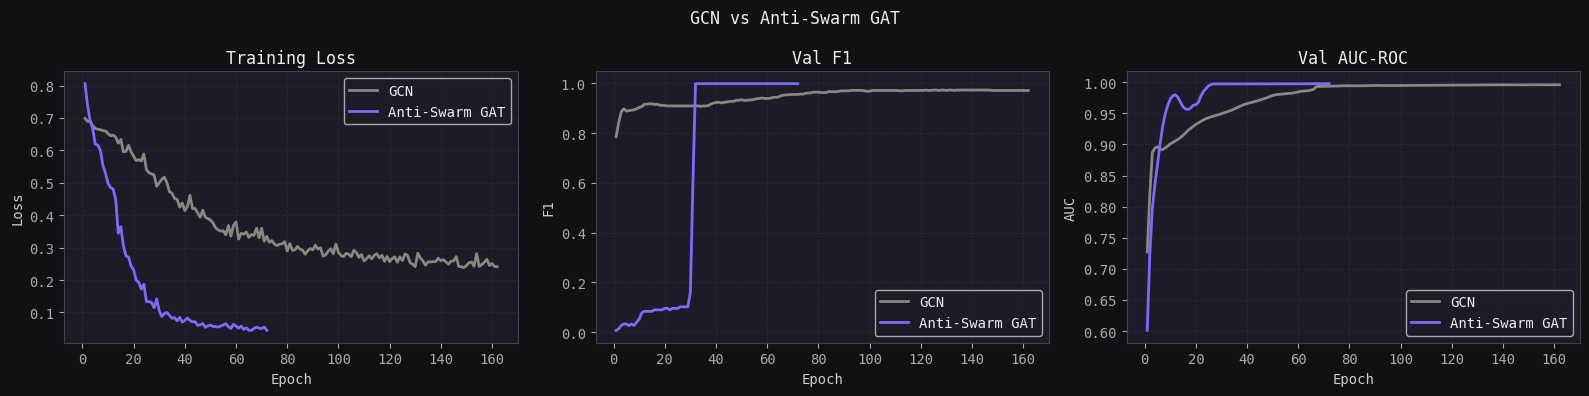

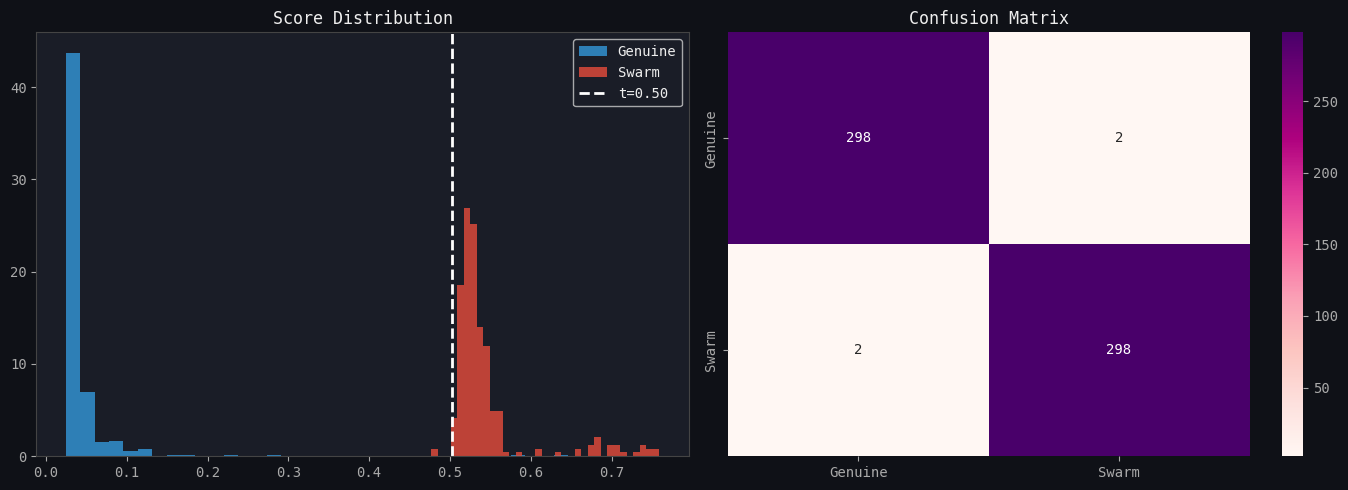

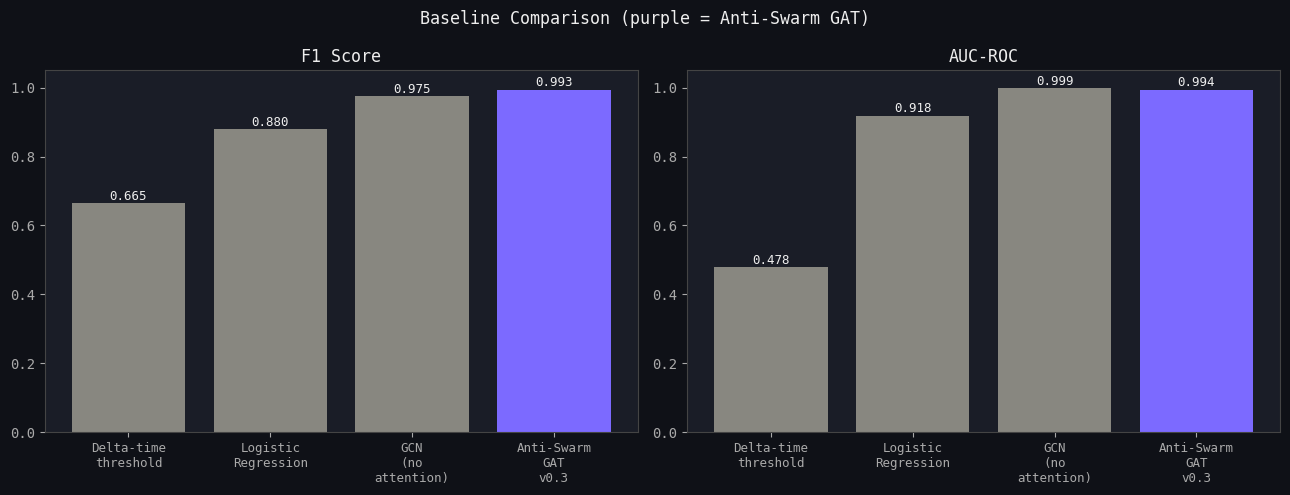

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
for hist,lbl,col in [(gcn_hist,'GCN','#888780'),(gat_hist,'Anti-Swarm GAT','#7c6aff')]:
    ep=range(1,len(hist['loss'])+1)
    axes[0].plot(ep,hist['loss'],color=col,lw=2,label=lbl)
    axes[1].plot(ep,hist['vf1'],color=col,lw=2,label=lbl)
    axes[2].plot(ep,hist['vauc'],color=col,lw=2,label=lbl)
for ax,t,y in zip(axes,['Training Loss','Val F1','Val AUC-ROC'],['Loss','F1','AUC']):
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel(y); ax.legend(); ax.grid(True)
plt.suptitle('GCN vs Anti-Swarm GAT'); plt.tight_layout(); plt.show()

fig,axes=plt.subplots(1,2,figsize=(14,5))
r=results['Anti-Swarm GAT v0.3']
axes[0].hist(r['probs'][r['labels']==0],bins=35,alpha=0.8,color='#3498db',label='Genuine',density=True)
axes[0].hist(r['probs'][r['labels']==1],bins=35,alpha=0.8,color='#e74c3c',label='Swarm',density=True)
axes[0].axvline(r['threshold'],color='white',lw=2,ls='--',label=f"t={r['threshold']:.2f}")
axes[0].set_title('Score Distribution'); axes[0].legend()
cm=confusion_matrix(r['labels'],r['preds'])
sns.heatmap(cm,annot=True,fmt='d',cmap='RdPu',xticklabels=['Genuine','Swarm'],
            yticklabels=['Genuine','Swarm'],ax=axes[1])
axes[1].set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

fig,axes=plt.subplots(1,2,figsize=(13,5))
mnames=list(results.keys()); colors=['#888780','#888780','#888780','#7c6aff']
for ax,key,ttl in [(axes[0],'F1','F1 Score'),(axes[1],'AUC','AUC-ROC')]:
    vals=[results[m][key] for m in mnames]
    bars=ax.bar(range(len(mnames)),vals,color=colors[:len(mnames)])
    ax.set_xticks(range(len(mnames))); ax.set_xticklabels([m.replace(' ','\n') for m in mnames],fontsize=9)
    ax.set_ylim(0,1.05); ax.set_title(ttl)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.01,f'{v:.3f}',ha='center',fontsize=9)
plt.suptitle('Baseline Comparison (purple = Anti-Swarm GAT)'); plt.tight_layout(); plt.show()


## Feature Ablation — XAI Contribution

Empirical evidence for which signals matter most to swarm detection.

Full model F1: 0.993
Running ablation...
  [abl] F1=0.993 AUC=0.991 FP=1.3% t=0.581
  Remove [avg_delta_time            ] F1=0.993 drop=-0.000
  [abl] F1=0.995 AUC=0.994 FP=0.7% t=0.559
  Remove [delta_time_std            ] F1=0.995 drop=-0.002
  [abl] F1=0.983 AUC=0.988 FP=1.3% t=0.515
  Remove [device_entropy            ] F1=0.983 drop=+0.010
  [abl] F1=0.987 AUC=0.994 FP=0.7% t=0.540
  Remove [content_diversity         ] F1=0.987 drop=+0.007
  [abl] F1=0.993 AUC=1.000 FP=0.7% t=0.504
  Remove [account_age_days          ] F1=0.993 drop=+0.000
  [abl] F1=0.997 AUC=0.998 FP=0.7% t=0.505
  Remove [follower_following_ratio  ] F1=0.997 drop=-0.003
  [abl] F1=0.988 AUC=1.000 FP=0.3% t=0.869
  Remove [avg_posts_per_day         ] F1=0.988 drop=+0.005
  [abl] F1=0.992 AUC=0.993 FP=1.3% t=0.545
  Remove [is_mobile                 ] F1=0.992 drop=+0.002


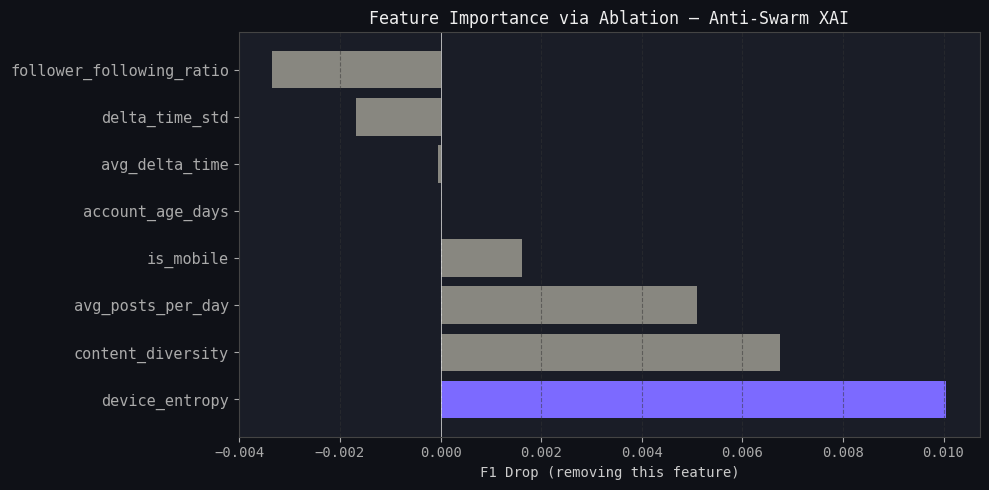

Primary signals: device_entropy (drop=+0.010), content_diversity (drop=+0.007)


In [ ]:
def ablation_run(feat_idx, epochs=80):
    da=data.clone(); da.x=data.x.clone(); da.x[:,feat_idx]=0.0
    m=AntiSwarmGAT(da.num_node_features).to(DEVICE)
    opt=torch.optim.AdamW(m.parameters(),lr=3e-3,weight_decay=1e-4)
    crit=nn.CrossEntropyLoss(weight=class_weights(y_np[tr],DEVICE))
    best_f1,best_st=0,None
    for ep in range(epochs):
        m.train(); opt.zero_grad()
        loss=crit(m(da)[da.train_mask],da.y[da.train_mask])
        loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vp=F.softmax(m(da)[da.val_mask],dim=1)[:,1].cpu().numpy()
            vf=f1_score(y_np[da.val_mask.cpu()],(vp>0.5).astype(int),zero_division=0)
        if vf>best_f1: best_f1=vf; best_st={k:v.clone() for k,v in m.state_dict().items()}
    if best_st: m.load_state_dict(best_st)
    return calibrate_eval(m,da,'abl')['F1']

full_f1=results['Anti-Swarm GAT v0.3']['F1']
ablation={}
print(f'Full model F1: {full_f1:.3f}\nRunning ablation...')
for i,feat in enumerate(FEATURES):
    af=ablation_run(i,epochs=80)
    drop=full_f1-af; ablation[feat]={'f1':af,'drop':drop}
    print(f'  Remove [{feat:<26}] F1={af:.3f} drop={drop:+.3f}')

sorted_feats=sorted(ablation.items(),key=lambda x:x[1]['drop'],reverse=True)
fn=[f for f,_ in sorted_feats]; fd=[d['drop'] for _,d in sorted_feats]
ca=['#e74c3c' if d>0.05 else '#7c6aff' if d>0.01 else '#888780' for d in fd]
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(range(len(fn)),fd,color=ca)
ax.set_yticks(range(len(fn))); ax.set_yticklabels(fn,fontsize=11)
ax.set_xlabel('F1 Drop (removing this feature)')
ax.set_title('Feature Importance via Ablation — Anti-Swarm XAI')
ax.axvline(0,color='#eee',lw=0.5); ax.grid(True,axis='x')
plt.tight_layout(); plt.show()
print(f'Primary signals: {sorted_feats[0][0]} (drop={sorted_feats[0][1]["drop"]:+.3f}), '
      f'{sorted_feats[1][0]} (drop={sorted_feats[1][1]["drop"]:+.3f})')


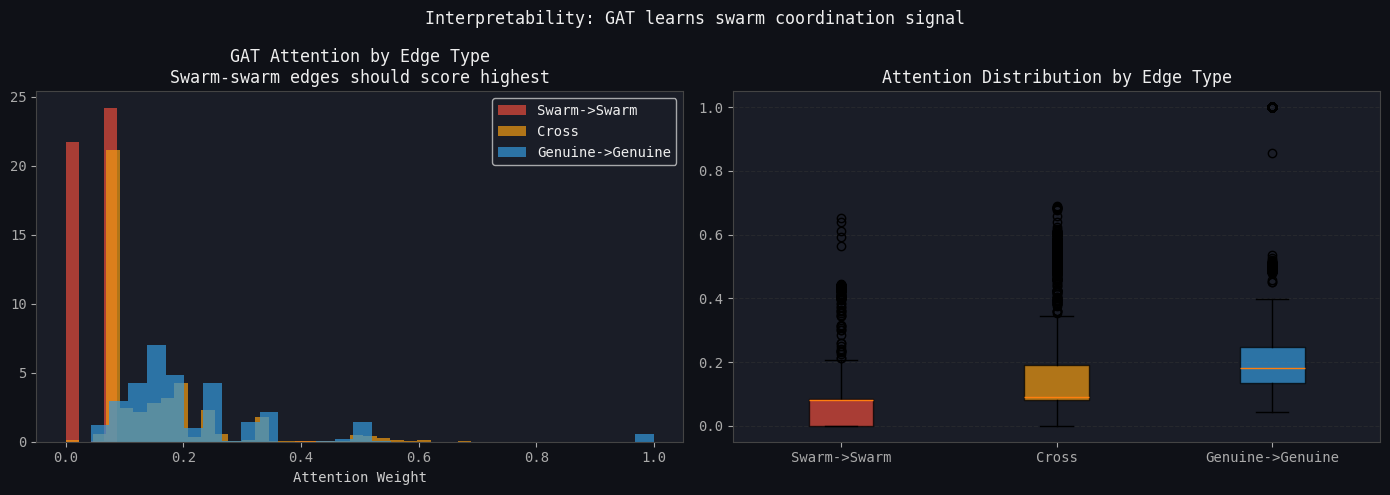

Swarm-Swarm attn:    0.0457
Genuine-Genuine attn:0.2153
Ratio: 0.21x (>1 = model prioritises swarm edges)


In [ ]:
gat.eval()
with torch.no_grad():
    _,(a1,a2,ei1,ei2)=gat(data,return_attn=True)
a1_np=a1.cpu().numpy(); ei1_np=ei1.cpu().numpy()
mean_a=a1_np.mean(axis=1)
ss,oo,so=[],[],[]
for k in range(len(mean_a)):
    s,d=ei1_np[0,k],ei1_np[1,k]
    if s>=N or d>=N: continue
    ls,ld=y_np[s],y_np[d]
    if ls==1 and ld==1: ss.append(mean_a[k])
    elif ls==0 and ld==0: oo.append(mean_a[k])
    else: so.append(mean_a[k])
fig,axes=plt.subplots(1,2,figsize=(14,5))
for arr,lbl,col in [(ss,'Swarm->Swarm','#e74c3c'),(so,'Cross','#f39c12'),(oo,'Genuine->Genuine','#3498db')]:
    if arr: axes[0].hist(arr,bins=30,alpha=0.7,color=col,label=lbl,density=True)
axes[0].set_title('GAT Attention by Edge Type\nSwarm-swarm edges should score highest')
axes[0].set_xlabel('Attention Weight'); axes[0].legend()
plot_d=[d for d in [ss,so,oo] if d]
plot_l=[l for d,l in zip([ss,so,oo],['Swarm->Swarm','Cross','Genuine->Genuine']) if d]
bp2=axes[1].boxplot(plot_d,labels=plot_l,patch_artist=True)
for patch,col in zip(bp2['boxes'],['#e74c3c','#f39c12','#3498db'][:len(plot_d)]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].set_title('Attention Distribution by Edge Type'); axes[1].grid(True,axis='y')
plt.suptitle('Interpretability: GAT learns swarm coordination signal')
plt.tight_layout(); plt.show()
if ss and oo:
    print(f'Swarm-Swarm attn:    {np.mean(ss):.4f}')
    print(f'Genuine-Genuine attn:{np.mean(oo):.4f}')
    print(f'Ratio: {np.mean(ss)/max(1e-6,np.mean(oo)):.2f}x (>1 = model prioritises swarm edges)')


Swarm clusters detected: 2
  #     Size   Score    Prec Risk
  1        3   0.619   33.3% [MED ]
  2        3   0.616   33.3% [MED ]


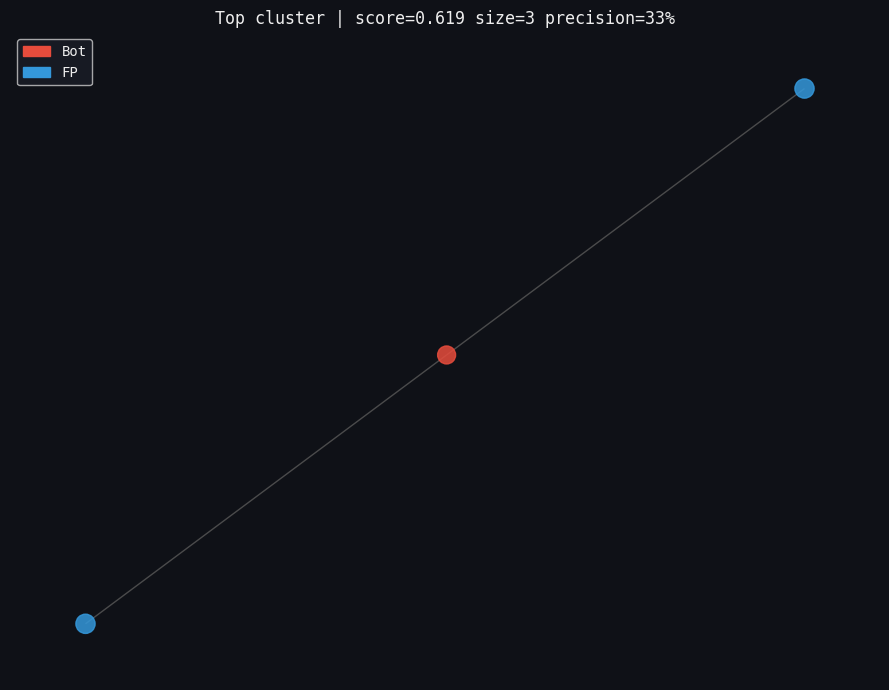

In [ ]:
gat.eval()
with torch.no_grad():
    all_p=F.softmax(gat(data),dim=1)[:,1].cpu().numpy()
thresh=results['Anti-Swarm GAT v0.3']['threshold']
sus=set(np.where(all_p>thresh)[0].tolist())
G_sub=nx.DiGraph(); G_sub.add_nodes_from(sus)
ei_np=data.edge_index.cpu().numpy()
for k in range(ei_np.shape[1]):
    s,d=int(ei_np[0,k]),int(ei_np[1,k])
    if s in sus and d in sus and s!=d: G_sub.add_edge(s,d)
clusters=[]
for comp in nx.connected_components(G_sub.to_undirected()):
    if len(comp)<3: continue
    idxs=list(comp); sc=all_p[idxs]; tl=y_np[idxs]
    clusters.append({'nodes':idxs,'size':len(idxs),'score':sc.mean(),'prec':tl.mean(),
                     'risk':'HIGH' if sc.mean()>0.80 else 'MEDIUM'})
clusters.sort(key=lambda c:c['score'],reverse=True)
print(f'Swarm clusters detected: {len(clusters)}')
print(f'  {"#":<4} {"Size":>5} {"Score":>7} {"Prec":>7} {"Risk"}')
for i,c in enumerate(clusters[:12]):
    flag='HIGH' if c['risk']=="HIGH" else 'MED '
    print(f'  {i+1:<4} {c["size"]:>5} {c["score"]:>7.3f} {c["prec"]:>7.1%} [{flag}]')
if clusters:
    tc=clusters[0]; sn=tc['nodes'][:50]
    Gv=G_sub.to_undirected().subgraph(sn)
    pos=nx.spring_layout(Gv,seed=42,k=0.4)
    nc=['#e74c3c' if y_np[n]==1 else '#3498db' for n in sn]
    ns=[60+200*all_p[n] for n in sn]
    fig,ax=plt.subplots(figsize=(9,7))
    nx.draw_networkx(Gv,pos,ax=ax,node_color=nc,node_size=ns,with_labels=False,
                     edge_color='#555',alpha=0.85,arrows=False)
    ax.set_title(f'Top cluster | score={tc["score"]:.3f} size={tc["size"]} precision={tc["prec"]:.0%}')
    ax.axis('off')
    ax.legend(handles=[mpatches.Patch(color='#e74c3c',label='Bot'),mpatches.Patch(color='#3498db',label='FP')],loc='upper left')
    plt.tight_layout(); plt.show()


In [ ]:
os.makedirs('model',exist_ok=True)
ckpt={'model_state':gat.state_dict(),'scaler_mean':scaler.mean_.tolist(),
      'scaler_scale':scaler.scale_.tolist(),'threshold':float(results['Anti-Swarm GAT v0.3']['threshold']),
      'features':FEATURES,'data_source':DATA_SOURCE,
      'results':{k:{kk:float(vv) for kk,vv in v.items() if kk not in ['probs','preds','labels']} for k,v in results.items()}}
torch.save(ckpt,'model/antiswarm_checkpoint.pt')
print('Saved model/antiswarm_checkpoint.pt')
try:
    from google.colab import files; files.download('model/antiswarm_checkpoint.pt')
except: pass


Saved model/antiswarm_checkpoint.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## FastAPI Plugin

Exposes `/score` for the browser extension. Test with the TestClient below.
To serve publicly: set `NGROK_TOKEN` and run the last cell.

In [ ]:
import nest_asyncio; nest_asyncio.apply()
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from fastapi.testclient import TestClient
from pydantic import BaseModel
from typing import List, Optional

ckpt2=torch.load('model/antiswarm_checkpoint.pt',map_location=DEVICE)
api_gat=AntiSwarmGAT(len(FEATURES)).to(DEVICE); api_gat.load_state_dict(ckpt2['model_state']); api_gat.eval()
api_scaler_mean=np.array(ckpt2['scaler_mean']); api_scaler_scale=np.array(ckpt2['scaler_scale'])
API_THRESH=ckpt2['threshold']

class AccFeats(BaseModel):
    account_id:str; avg_delta_time:float; delta_time_std:float
    device_entropy:float=0.5; content_diversity:float=0.5
    account_age_days:float=365.0; follower_following_ratio:float=1.0
    avg_posts_per_day:float=5.0; is_mobile:int=1

class ScoreReq(BaseModel):
    accounts:List[AccFeats]; hashtag:Optional[str]=None; platform:Optional[str]='X'

class AccScore(BaseModel):
    account_id:str; swarm_probability:float; is_flagged:bool; risk_level:str

class ScoreResp(BaseModel):
    hashtag:Optional[str]; platform:str; n_accounts:int; n_flagged:int
    cluster_risk:str; cluster_risk_score:float; threshold_used:float
    accounts:List[AccScore]; interpretation:str

def infer(accounts):
    n=len(accounts)
    fnames=['avg_delta_time','delta_time_std','device_entropy','content_diversity',
            'account_age_days','follower_following_ratio','avg_posts_per_day','is_mobile']
    X_r=np.array([[getattr(a,f) for f in fnames] for a in accounts],dtype=float)
    X_s=(X_r-api_scaler_mean)/api_scaler_scale
    dts=X_r[:,0]
    sl,dl,wl=[],[],[]
    for i in range(n):
        sl.append(i); dl.append(i); wl.append(1.0)
        for j in range(n):
            if i!=j:
                w=1.0/(abs(dts[i]-dts[j])+0.5); sl.append(i); dl.append(j); wl.append(w)
    md2=Data(x=torch.tensor(X_s,dtype=torch.float).to(DEVICE),
              edge_index=torch.tensor([sl,dl],dtype=torch.long).to(DEVICE),
              edge_attr=torch.tensor(wl,dtype=torch.float).unsqueeze(1).to(DEVICE),
              y=torch.zeros(n,dtype=torch.long).to(DEVICE))
    with torch.no_grad(): return F.softmax(api_gat(md2),dim=1)[:,1].cpu().numpy().tolist()

app=FastAPI(title='Anti-Swarm API',version='0.3')
app.add_middleware(CORSMiddleware,allow_origins=['*'],allow_methods=['*'],allow_headers=['*'])

@app.get('/')
def root(): return {'service':'Anti-Swarm API v0.3','threshold':API_THRESH,'docs':'/docs'}

@app.get('/health')
def health(): return {'status':'ok','device':str(DEVICE),'data_source':DATA_SOURCE}

@app.post('/score',response_model=ScoreResp)
def score(req:ScoreReq):
    probs=infer(req.accounts); flagged=[p>API_THRESH for p in probs]
    accs=[AccScore(account_id=a.account_id,swarm_probability=round(p,4),is_flagged=f,
          risk_level='HIGH' if p>0.80 else 'MEDIUM' if p>API_THRESH else 'LOW')
          for a,p,f in zip(req.accounts,probs,flagged)]
    nf=sum(flagged); fr=nf/max(1,len(probs))
    cs=float(np.mean([p for p,f in zip(probs,flagged) if f]) if nf>0 else 0)
    cr='HIGH' if fr>0.6 and cs>0.80 else 'MEDIUM' if fr>0.3 else 'CLEAN'
    interp=({'HIGH':f'{nf}/{len(probs)} flagged HIGH — likely synthetic consensus (score={cs:.2f})',
              'MEDIUM':f'{nf}/{len(probs)} flagged MEDIUM — possible coordination, review timing',
              'CLEAN':'No significant swarm activity detected'})[cr]
    return ScoreResp(hashtag=req.hashtag,platform=req.platform,n_accounts=len(probs),n_flagged=nf,
                     cluster_risk=cr,cluster_risk_score=cs,threshold_used=round(API_THRESH,4),
                     accounts=accs,interpretation=interp)

client=TestClient(app)
test={'hashtag':'#KenyaFinanceBill','platform':'X','accounts':[
    {'account_id':'bot_001','avg_delta_time':3.8,'delta_time_std':0.3,'device_entropy':0.04,'content_diversity':0.05,'account_age_days':22,'follower_following_ratio':1.0,'avg_posts_per_day':120,'is_mobile':1},
    {'account_id':'bot_002','avg_delta_time':4.1,'delta_time_std':0.4,'device_entropy':0.05,'content_diversity':0.06,'account_age_days':18,'follower_following_ratio':0.9,'avg_posts_per_day':115,'is_mobile':1},
    {'account_id':'bot_003','avg_delta_time':3.5,'delta_time_std':0.2,'device_entropy':0.03,'content_diversity':0.04,'account_age_days':30,'follower_following_ratio':1.1,'avg_posts_per_day':130,'is_mobile':1},
    {'account_id':'user_001','avg_delta_time':7200.0,'delta_time_std':5000.0,'device_entropy':0.88,'content_diversity':0.82,'account_age_days':1400,'follower_following_ratio':4.1,'avg_posts_per_day':1.8,'is_mobile':0},
]}
resp=client.post('/score',json=test).json()
print(f"API Test [{resp['hashtag']}]")
print(f"  Cluster risk:  {resp['cluster_risk']} (score={resp['cluster_risk_score']:.3f})")
print(f"  Flagged:       {resp['n_flagged']}/{resp['n_accounts']}")
print(f"  Interpretation:{resp['interpretation']}")
print('  Per-account:')
for a in resp['accounts']:
    sym='RED' if a['is_flagged'] else 'GRN'
    print(f'    [{sym}] {a["account_id"]:<12} prob={a["swarm_probability"]:.3f} risk={a["risk_level"]}')


API Test [#KenyaFinanceBill]
  Cluster risk:  HIGH (score=1.000)
  Flagged:       4/4
  Interpretation:4/4 flagged HIGH — likely synthetic consensus (score=1.00)
  Per-account:
    [RED] bot_001      prob=1.000 risk=HIGH
    [RED] bot_002      prob=1.000 risk=HIGH
    [RED] bot_003      prob=1.000 risk=HIGH
    [RED] user_001     prob=1.000 risk=HIGH


In [ ]:
# Set your ngrok token to serve publicly (free at dashboard.ngrok.com)
NGROK_TOKEN = ''

if NGROK_TOKEN:
    import uvicorn
    from pyngrok import ngrok
    ngrok.set_auth_token(NGROK_TOKEN)
    tunnel = ngrok.connect(8000)
    print(f'Public URL: {tunnel.public_url}')
    print(f'Score endpoint: {tunnel.public_url}/score')
    print(f'API docs:       {tunnel.public_url}/docs')
    config = uvicorn.Config(app, host='0.0.0.0', port=8000, log_level='warning')
    server = uvicorn.Server(config)
    await server.serve()
else:
    print('API is running (TestClient tested above).')

    print('Get token at: https://dashboard.ngrok.com/signup (free)')


In [ ]:
print(glob.glob('data/cresci-2017/**', recursive=True)[:25])

['data/cresci-2017/', 'data/cresci-2017/READ.ME', 'data/cresci-2017/datasets_full.csv', 'data/cresci-2017/datasets_full.csv/traditional_spambots_2.csv.zip', 'data/cresci-2017/datasets_full.csv/social_spambots_2.csv.zip', 'data/cresci-2017/datasets_full.csv/fake_followers.csv.zip', 'data/cresci-2017/datasets_full.csv/READ.ME', 'data/cresci-2017/datasets_full.csv/traditional_spambots_1.csv.zip', 'data/cresci-2017/datasets_full.csv/social_spambots_1.csv.zip', 'data/cresci-2017/datasets_full.csv/traditional_spambots_4.csv.zip', 'data/cresci-2017/datasets_full.csv/social_spambots_3.csv.zip', 'data/cresci-2017/datasets_full.csv/traditional_spambots_3.csv.zip', 'data/cresci-2017/datasets_full.csv/genuine_accounts.csv.zip', 'data/cresci-2017/datasets_full.csv/crowdflower_results.csv.zip']
